In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import seaborn as sns

Using drive here to reference new dataset: EIA-861 Annual Electric Power Industry Report
download at: https://www.eia.gov/electricity/data/state/

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
path = '/content/drive/MyDrive/HS861 1960-1989.xlsx'
df = pd.read_excel(path)
df.head()

,Unnamed: 0,Unnamed: 1,RESIDENTIAL,Unnamed: 3,Unnamed: 4,Unnamed: 5,COMMERCIAL,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 16,Unnamed: 17,OTHER,Unnamed: 19,Unnamed: 20,Unnamed: 21,TOTAL,Unnamed: 23,Unnamed: 24,Unnamed: 25
0,NaN,NaN,Revenues,Sales,Customers,Price,Revenues,Sales,Customers,Price,...,Customers,Price,Revenues,Sales,Customers,Price,Revenues,Sales,Customers,Price
1,YEAR,STATE,Thousand Dollars,Megawatthours,Count,Cents/kWh,Thousand Dollars,Megawatthours,Count,Cents/kWh,...,Count,Cents/kWh,Thousand Dollars,Megawatthours,Count,Cents/kWh,Thousand Dollars,Megawatthours,Count,Cents/kWh
2,1989,AK,161165,1643441,193370,9.81,166129,1896990,30854,8.76,...,NaN,NaN,19783,150876,4058,13.11,381967,4141674,228800,9.22
3,1989,AL,1306594,19842377,1638602,6.58,711948,10516594,217036,6.77,...,NaN,NaN,33181,596283,11291,5.56,3233277,58187349,1876242,5.56
4,1989,AR,774211,9957250,977653,7.78,400672,5982183,110077,6.7,...,NaN,NaN,38864,583850,17860,6.66,1681388,26084949,1127121,6.45


In [9]:
df = pd.read_excel(path, header=None)

# Get the first two rows which contain the column headers
top_header = df.iloc[0]
sub_header = df.iloc[1]

# Forward fill the top-level categories (RESIDENTIAL, COMMERCIAL, etc.)
top_header_filled = top_header.fillna(method='ffill')

# Create new column names by combining top and sub headers
new_columns = []

# Explicitly set the first two column names as 'YEAR' and 'STATE'
new_columns.append('YEAR')
new_columns.append('STATE')

# Iterate from the third column onwards for combined headers
for i, (top, sub) in enumerate(zip(top_header_filled[2:], sub_header[2:]), start=2):
    # If the top header is 'Unnamed', use only the sub header
    if 'Unnamed' in str(top):
        new_columns.append(sub)
    else:
        new_columns.append(f"{top} {sub}")

# Set the new columns to the DataFrame
df.columns = new_columns

# Drop the original header rows (which are now the first two data rows)
df = df.drop(index=[0, 1]).reset_index(drop=True)
df.head()

/tmp/ipython-input-965930643.py:8: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  top_header_filled = top_header.fillna(method='ffill')


,YEAR,STATE,RESIDENTIAL Revenues,RESIDENTIAL Sales,RESIDENTIAL Customers,RESIDENTIAL Price,COMMERCIAL Revenues,COMMERCIAL Sales,COMMERCIAL Customers,COMMERCIAL Price,...,TRANSPORTATION Customers,TRANSPORTATION Price,OTHER Revenues,OTHER Sales,OTHER Customers,OTHER Price,TOTAL Revenues,TOTAL Sales,TOTAL Customers,TOTAL Price
0,YEAR,STATE,Thousand Dollars,Megawatthours,Count,Cents/kWh,Thousand Dollars,Megawatthours,Count,Cents/kWh,...,Count,Cents/kWh,Thousand Dollars,Megawatthours,Count,Cents/kWh,Thousand Dollars,Megawatthours,Count,Cents/kWh
1,1989,AK,161165,1643441,193370,9.81,166129,1896990,30854,8.76,...,NaN,NaN,19783,150876,4058,13.11,381967,4141674,228800,9.22
2,1989,AL,1306594,19842377,1638602,6.58,711948,10516594,217036,6.77,...,NaN,NaN,33181,596283,11291,5.56,3233277,58187349,1876242,5.56
3,1989,AR,774211,9957250,977653,7.78,400672,5982183,110077,6.7,...,NaN,NaN,38864,583850,17860,6.66,1681388,26084949,1127121,6.45
4,1989,AZ,1348821,15247500,1389809,8.85,1056539,13036593,157943,8.1,...,NaN,NaN,129597,2741471,21724,4.73,3059078,40747595,1573760,7.51


In [10]:
# Get the current column names and the values from the first data row
current_column_names = df.columns.tolist()
first_row_values = df.iloc[0].tolist()

# Create new column names based on the logic
refined_column_names = []
for col_name, first_row_val in zip(current_column_names, first_row_values):
    if col_name == first_row_val:
        refined_column_names.append(col_name)
    else:
        refined_column_names.append(f"{col_name} ({first_row_val})")

# Assign the new column names to the DataFrame
df.columns = refined_column_names

# Drop the first row as its information has now been incorporated into the column names
df = df.drop(index=0).reset_index(drop=True)

df.head()

,YEAR,STATE,RESIDENTIAL Revenues (Thousand Dollars),RESIDENTIAL Sales (Megawatthours),RESIDENTIAL Customers (Count),RESIDENTIAL Price (Cents/kWh),COMMERCIAL Revenues (Thousand Dollars),COMMERCIAL Sales (Megawatthours),COMMERCIAL Customers (Count),COMMERCIAL Price (Cents/kWh),...,TRANSPORTATION Customers (Count),TRANSPORTATION Price (Cents/kWh),OTHER Revenues (Thousand Dollars),OTHER Sales (Megawatthours),OTHER Customers (Count),OTHER Price (Cents/kWh),TOTAL Revenues (Thousand Dollars),TOTAL Sales (Megawatthours),TOTAL Customers (Count),TOTAL Price (Cents/kWh)
0,1989,AK,161165,1643441,193370,9.81,166129,1896990,30854,8.76,...,NaN,NaN,19783,150876,4058,13.11,381967,4141674,228800,9.22
1,1989,AL,1306594,19842377,1638602,6.58,711948,10516594,217036,6.77,...,NaN,NaN,33181,596283,11291,5.56,3233277,58187349,1876242,5.56
2,1989,AR,774211,9957250,977653,7.78,400672,5982183,110077,6.7,...,NaN,NaN,38864,583850,17860,6.66,1681388,26084949,1127121,6.45
3,1989,AZ,1348821,15247500,1389809,8.85,1056539,13036593,157943,8.1,...,NaN,NaN,129597,2741471,21724,4.73,3059078,40747595,1573760,7.51
4,1989,CA,6080325,64347201,10249986,9.45,6866744,75282288,1404930,9.12,...,NaN,NaN,399635,8913327,42690,4.48,17309281,204138770,11735817,8.48


In [11]:
df.columns

Index(['YEAR', 'STATE', 'RESIDENTIAL Revenues (Thousand Dollars)',
       'RESIDENTIAL Sales (Megawatthours)', 'RESIDENTIAL Customers (Count)',
       'RESIDENTIAL Price (Cents/kWh)',
       'COMMERCIAL Revenues (Thousand Dollars)',
       'COMMERCIAL Sales (Megawatthours)', 'COMMERCIAL Customers (Count)',
       'COMMERCIAL Price (Cents/kWh)',
       'INDUSTRIAL Revenues (Thousand Dollars)',
       'INDUSTRIAL Sales (Megawatthours)', 'INDUSTRIAL Customers (Count)',
       'INDUSTRIAL Price (Cents/kWh)',
       'TRANSPORTATION Revenues (Thousand Dollars)',
       'TRANSPORTATION Sales (Megawatthours)',
       'TRANSPORTATION Customers (Count)', 'TRANSPORTATION Price (Cents/kWh)',
       'OTHER Revenues (Thousand Dollars)', 'OTHER Sales (Megawatthours)',
       'OTHER Customers (Count)', 'OTHER Price (Cents/kWh)',
       'TOTAL Revenues (Thousand Dollars)', 'TOTAL Sales (Megawatthours)',
       'TOTAL Customers (Count)', 'TOTAL Price (Cents/kWh)'],
      dtype='object')

In [23]:
sales_cols = [col for col in df.columns if 'Sales (Megawatthours)' in col]
print(sales_cols)

['RESIDENTIAL Sales (Megawatthours)', 'COMMERCIAL Sales (Megawatthours)', 'INDUSTRIAL Sales (Megawatthours)', 'TRANSPORTATION Sales (Megawatthours)', 'OTHER Sales (Megawatthours)', 'TOTAL Sales (Megawatthours)']


In [24]:
sales_cols = sales_cols[:-2]
print(sales_cols)

['RESIDENTIAL Sales (Megawatthours)', 'COMMERCIAL Sales (Megawatthours)', 'INDUSTRIAL Sales (Megawatthours)', 'TRANSPORTATION Sales (Megawatthours)']


Plot sales per year in Ca for each distinct category (e.g. industrial, residential, total, etc)

In [25]:
# Filter data for California only
df_california = df[df['STATE'] == 'CA']
df_california['YEAR'] = pd.to_numeric(df_california['YEAR'], errors='coerce')
for col in sales_cols:
    df_california[col] = pd.to_numeric(df_california[col], errors='coerce').fillna(0)
yearly_sales_california = df_california.groupby('YEAR')[sales_cols].sum().reset_index()

/tmp/ipython-input-3019855450.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_california['YEAR'] = pd.to_numeric(df_california['YEAR'], errors='coerce')
/tmp/ipython-input-3019855450.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_california[col] = pd.to_numeric(df_california[col], errors='coerce').fillna(0)


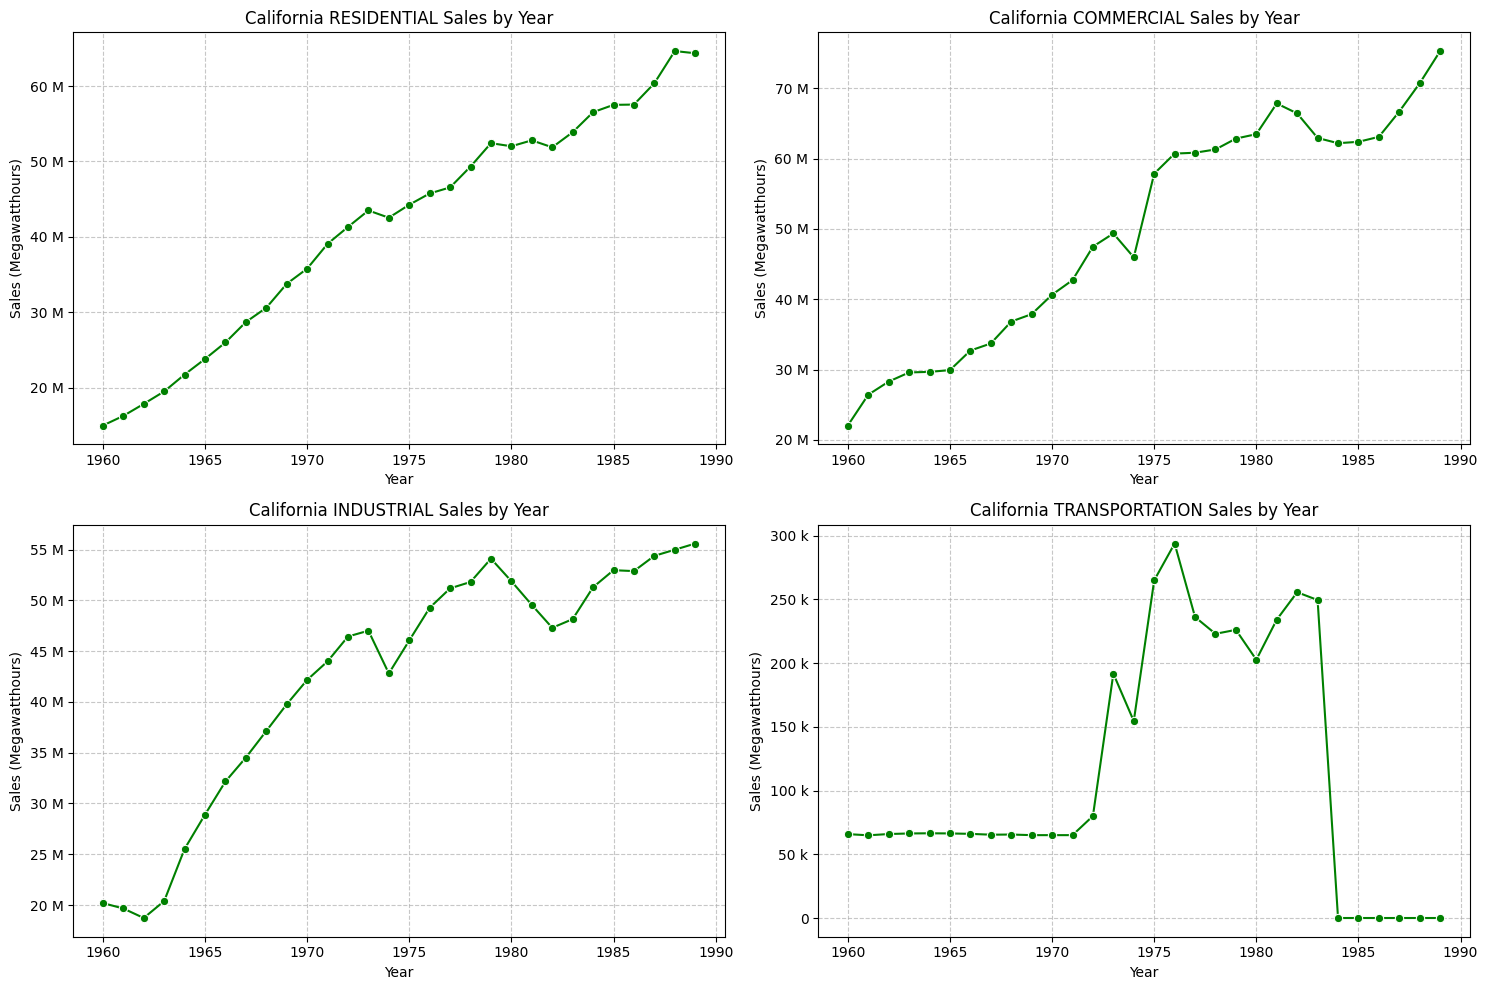

In [26]:
# Separate individual categories from total sales for plotting
category_sales_cols_california = [col for col in sales_cols if 'TOTAL' not in col]
total_sales_col_california = 'TOTAL Sales (Megawatthours)'

num_plots_ca = len(category_sales_cols_california)
num_cols_ca = 2
num_rows_ca = (num_plots_ca + num_cols_ca - 1) // num_cols_ca

plt.figure(figsize=(15, 5 * num_rows_ca))

for i, col in enumerate(category_sales_cols_california):
    plt.subplot(num_rows_ca, num_cols_ca, i + 1)
    sns.lineplot(x='YEAR', y=col, data=yearly_sales_california, marker='o', color='green')
    plt.title(f'California {col.replace(" Sales (Megawatthours)", "")} Sales by Year')
    plt.xlabel('Year')
    plt.ylabel('Sales (Megawatthours)')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.gca().yaxis.set_major_formatter(ticker.EngFormatter())
    plt.ticklabel_format(style='plain', axis='y')

plt.tight_layout()
plt.show()

Based on the plots above, we have the following takeaways:
1. its clear that the different categories for electricity sales follow different patterns, which tells us that it would be sensible to focus our research question down to isolate a single category (e.g. industrial, commerical)
2. It would also be logical to include economic events like economic depressions as a potential confounder to explain periods of volatility in our time series.
3. We will likely use month, year, state granularity to ensure we have sufficient datapoints for meaningful analysis, which will require us to supplement with additional data